# scGPT Perturbation Attention Pipeline

**Notebook Principal de Análisis de Atención Diferencial y Enriquecimiento Funcional para perturbaciones génicas con scGPT fine-tuneado**

## Etapas del Flujo de Trabajo

1. **Cargar dataset y Preprocesamiento:** Carga de las matrices (`.h5ad`) de las anotaciones celulares (`obs`) y nombres de genes (`var`). Se implementa un control para identificar si el dataset viene normalizado y si no es el caso, entonces preprocesarlo.
2. **Preservación del Fondo Estadístico (*Background*):** Captura de todos los genes del dataset expresados y mapeados en el vocabulario de scGPT **antes** de los filtros. Usados posteriormente para el análisis funcional.
3. **Filtrado y Selección Forzada:** Selección de los 2,000 genes altamente variables (HVGs). El gen perturbado entra dentro de esta selección.
4. **Tokenización y Forward Parcial:** Transformación de la matriz binned de expresión en secuencias de tokens (identidad + valor de expresión) añadiendo el token global `<cls>`. Forward parcial de los tensores a través de las capas del codificador del Transformer (capas 0 a 10).
5. **Extracción Manual de Atención (Capa 11):** Extracción de los pesos del modelo en su última capa. Se extraen directamente las matrices Query ($Q$) y Key ($K$) para calcular la matriz ($Q \times K^T$).
6. **Normalización por Rangos Bidireccional:** Se aplica una doble normalización por rangos no paramétrica (primero en filas y luego en columnas) antes de promediar las matrices por condición (`attn_PERT` y `attn_CTRL`).
7. **Scoring Diferencial y Análisis Funcional:** 
    * **Método get_topk_most_influenced_genes:** Puntuación basada en la diferencia absoluta de la atención entrante total por gen.
    * **Método get_gene_cls_scores:** Análisis específico de la fila 0 (token `<cls>`), determinando qué genes modifican su atención.
8. **Enriquecimiento Biológico (g:Profiler):** Mapeo automatizado del *top* de genes influenciados contra bases de datos funcionales (Gene Ontology: Biological Process, KEGG, Reactome) utilizando el background que habíamos guardado.

---

## Instrucciones de uso y Adaptabilidad

Para adaptar el pipeline a otro tipo de datos (ej. *Adamson* o *TianKampmann2021*), **sólo es necesario modificar las variables de la Sección 1.2 (Configuración)**:

* `GEN_PERTURBADO`: Nombre oficial del gen diana (ej. `"TAF1"`, `"CREB1"`).
* `PERT_LABEL`: String exacto que identifica la condición en la columna correspondiente del fichero `.h5ad` (ej. `"TAF1+ctrl"`).
* `DATA_PATH`: Ruta hacia el archivo de datos procesados.
* `MODEL_DIR`: Ruta hacia los pesos (`best_model.pt`) del modelo scGPT fine-tuneado específicamente para ese conjunto de datos.

## 1. Configuración, hiperparámetros y métricas finales del modelo fine-tuneado

Hemos utilizado el modelo de scGPT al que le hemos aplicado un fine-tuning con el conjunto de datos de **``TianKampmann2021``** el cual puede obtenerse del repositorio de bases de datos de **scPerturb**. 

Este dataset cuenta con 185 perturbaciones creadas con la herramienta CRISPRi donde se silencian los niveles de expresión de los genes y cuenta con un total de 32.300 células y 33538 genes.

En este caso, el modelo fue entrenado utilizando una estrategia de fine-tuning parcial. En esta estrategia planteamos congelar los embedding previos al encoder y la última mitad de las capas del encoder, es decir, las 6 últimas capas, permitiendo únicamente actualizar los pesos de las capas iniciales. De esta manera reducimos el sobreajuste y prevenimos el olvido de las partes más genéricas de la biología celular del modelo. Además, reducimos el coste computacional al tener que entrenar menos parámetros.

Los ``hiperparámetros`` fueron los siguientes:
* **lr** = 1e-4  
* **weight_decay** = 1e-4
* **batch_size** = 12
* **eval_batch_size** = 12
* **epochs** = 30
* **schedule_interval** = 1
* **early_stop** = 10
* **embsize** = 512  
* **d_hid** = 512  
* **nlayers** = 12  
* **nhead** = 8  
* **n_layers_cls** = 3
* **dropout** = 0  
* **use_fast_transformer** = False  

Con esta estrategia de fine-tuning y estos hiperparámetros obtuvimos las siguientres métricas sobre el conjunto de test:

* **pearson_delta**: 0.221
* **pearson_delta_de**: 0.6457

El ``pearson_delta`` en vez de correlacionar los perfiles absolutos, mide la correlación entre la diferencia entre el cambio predicho (diferencia entre la predicción y la célula control) y el cambio real (diferencia entre la célula perturbada real y la
célula control). Evalúa la magnitud y dirección de los valores de expresión tras la perturbación sobre todos los genes.

El ``pearson_delta_de`` evalúa lo mismo que pearson_delta pero tan solo con los 20 genes más diferenciamente expresados.

## 1.1. Librerías

In [6]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import torch.nn as nn
import torchtext
from einops import rearrange
from peft import PeftModel
from scipy.sparse import issparse
from scipy.stats import pearsonr
from tqdm import tqdm
from gprofiler import GProfiler

sys.path.insert(0, "../")
from scgpt.model import TransformerModel
from scgpt.preprocess import Preprocessor
from scgpt.tokenizer import tokenize_and_pad_batch
from scgpt.tokenizer.gene_tokenizer import GeneVocab
from scgpt.utils import set_seed

warnings.filterwarnings("ignore")
set_seed(123)
sc.settings.verbosity = 1

## 1.2. Configuración

In [7]:
# Perturbación de interés 
GEN_PERTURBADO = "TAF1"                    # Nombre del gen a perturbar
PERT_LABEL     = "TAF1+ctrl"               # Etiqueta exacta en adata.obs[CONDITION_COL]
CTRL_LABEL     = "ctrl"                     # Etiqueta de células control (sin perturbar)

# Rutas 
DATA_PATH  = "./auxData/TianKampmann2021_CRISPRi.h5ad"         # Ruta del dataset
MODEL_DIR  = Path("./save/TianKampmann_i_Parcial/")            # Modelo scGPT fine-tuneado
CONF_DIR   = Path("./save/scGPT_human")                        # vocab + args.json de scGPT
ADAPTER_DIR = None  

# Columna de condición en adata.obs 
CONDITION_COL = "condition"

# Hiperparámetros scGPT
PAD_TOKEN      = "<pad>"
SPECIAL_TOKENS = [PAD_TOKEN, "<cls>", "<eoc>"]
PAD_VALUE      = -2
N_BINS         = 51
NUM_ATTN_LAYERS = 11          # 12 capas (11 última)
N_HVG           = 2000        # Nº de HVGs
TOP_K_GENES     = 200         # Nº de genes top para el enriquecimiento funcional
BATCH_SIZE      = 4

# Cuda 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"\nPerturbación a analizar : {PERT_LABEL}")
print(f"Gen perturbado          : {GEN_PERTURBADO}")

Device: cuda

Perturbación a analizar : TAF1+ctrl
Gen perturbado          : TAF1


## 1.3. Vocabulario y configuración del modelo

scGPT mapea cada gen a un ID entero mediante un vocabulario de >60k genes con el que scGPT fue entrenado. Los hiperparámetros de arquitectura se leen del `args.json` del modelo scGPT preentrenado.

In [8]:
vocab = GeneVocab.from_file(CONF_DIR / "vocab.json")
for s in SPECIAL_TOKENS:
    if s not in vocab:
        vocab.append_token(s)

with open(CONF_DIR / "args.json") as f:
    model_configs = json.load(f)

EMBSIZE      = model_configs["embsize"]
NHEAD        = model_configs["nheads"]
D_HID        = model_configs["d_hid"]
NLAYERS      = model_configs["nlayers"]
N_LAYERS_CLS = model_configs.get("n_layers_cls", 3)

print(f"Vocabulario : {len(vocab):,} genes")
print(f"Embedding   : {EMBSIZE}")
print(f"Heads       : {NHEAD}")
print(f"Capas       : {NLAYERS}")

Vocabulario : 60,697 genes
Embedding   : 512
Heads       : 8
Capas       : 12


## 2. Carga y preprocesado de datos

1. **Lectura y ajuste de Metadatos:** Carga de la matriz (`.h5ad`) y ajuste de las variables (mapeo de variables específicas del dataset como `perturbation` y `celltype` hacia los estándares del modelo: `condition` y `cell_type`). Para los datasets que vienen con variables con otro nombre, se deberán de ajustar las variables para que scGPT pueda interpretarlas.
2. **Evaluación del Estado de Expresión:** Inspección automatizada de los valores de la matriz para verificar si los datos ya cuentan con una normalización total previa y transformación logarítmica (`log1p`).
3. **Alineación con el Vocabulario scGPT:** Filtrado de la matriz para conservar únicamente los genes mapeados dentro del vocabulario global con el que fue preentrenado el modelo de scGPT.
4. **Preservación del Fondo Estadístico (*Background*):** Capturamos los genes tras el filtro de vocabulario. Se utilizará para realizar el **enriquecimiento funcional**.
5. **Selección de HVGs con Inclusión Forzada:** Filtrado de la matriz de expresión para conservar los 2,000 genes altamente variables (*Highly Variable Genes*).
6. **Discretización (*Binning*):** Transformación de los niveles continuos de expresión en índices discretos utilizando el módulo `Preprocessor` de scGPT.

In [ ]:
# 2.1 Cargar dataset completo
adata_full = sc.read_h5ad(DATA_PATH)

# --- ADAPTACIÓN PARA TianKampmann2021_CRISPRi ---
# Homogeneizar los metadatos para que coincidan con la estructura que espera scGPT
if 'perturbation' in adata_full.obs.columns:
    adata_full.obs['condition'] = adata_full.obs['perturbation'].astype(str)
    adata_full.obs['condition'] = adata_full.obs['condition'].apply(
        lambda x: 'ctrl' if x == 'control' else f"{x}+ctrl"
    )

if 'celltype' in adata_full.obs.columns:
    adata_full.obs['cell_type'] = adata_full.obs['celltype'].astype(str)

# Asegurar que el índice de genes es un string (clave para el match del vocabulario)
adata_full.var.index = adata_full.var.index.astype(str)
adata_full.var['gene_name'] = adata_full.var.index
# ------------------------------------------------

# Ahora sí, filtramos por la condición de interés usando las variables definidas
adata = adata_full[
    adata_full.obs[CONDITION_COL].isin([CTRL_LABEL, PERT_LABEL])
].copy()

print(f"Células cargadas : {adata.shape[0]:,} × {adata.shape[1]:,} genes")
print(f"Condiciones      : {adata.obs[CONDITION_COL].value_counts().to_dict()}")

if "gene_name" in adata.var.columns:
    adata.var.set_index("gene_name", inplace=True)

# 2.2 Detección automática del estado de preprocesamiento
_check = Preprocessor(use_key="X")
data_is_logged = _check.check_logged(adata)

X_check = adata.X.toarray() if issparse(adata.X) else adata.X
data_is_normalized = X_check.max() < 20  # log1p(1e4) ≈ 9.2, rara vez supera 15

print(f"¿Datos log1p?        : {data_is_logged}")
print(f"¿Datos normalizados? : {data_is_normalized}")

normalize_total = False if data_is_normalized else 1e4
apply_log1p     = not data_is_logged
hvg_flavor      = "seurat_v3" if (not data_is_logged and not data_is_normalized) else "cell_ranger"

if not data_is_normalized:
    print("  → Se aplicará normalización total (1e4)")
if apply_log1p:
    print("  → Se aplicará log1p")
if data_is_normalized and data_is_logged:
    print("  → Datos ya preprocesados, solo se aplica binning")
print(f"  → HVG flavor: {hvg_flavor}")

# 2.3 Filtro de vocabulario scGPT (ANTES del binning)
adata.var["id_in_vocab"] = [1 if g in vocab else -1 for g in adata.var.index]
adata = adata[:, adata.var["id_in_vocab"] >= 0].copy()
print(f"Tras filtro vocab : {adata.shape[0]:,} × {adata.shape[1]:,} genes")

# 2.4 Background capturado ANTES del filtro HVG
background_genes = adata.var.index.tolist()
print(f"\nBackground para enriquecimiento: {len(background_genes):,} genes")

# 2.5 Filtro HVG + forzar gen perturbado
sc.pp.highly_variable_genes(adata, n_top_genes=N_HVG, flavor=hvg_flavor, subset=False)

if GEN_PERTURBADO in adata.var.index:
    adata.var.loc[GEN_PERTURBADO, "highly_variable"] = True
    print(f"Gen perturbado '{GEN_PERTURBADO}' forzado en el conjunto de genes.")
else:
    print(f"AVISO: '{GEN_PERTURBADO}' no encontrado en el vocabulario/datos.")

adata = adata[:, adata.var["highly_variable"]].copy()
print(f"Tras filtro HVG  : {adata.shape[0]:,} × {adata.shape[1]:,} genes")

# 2.6 Binning (sobre los genes ya filtrados)
preprocessor = Preprocessor(
    use_key="X",
    filter_gene_by_counts=False,
    filter_cell_by_counts=False,
    normalize_total=normalize_total,
    result_normed_key="X_normed",
    log1p=apply_log1p,
    result_log1p_key="X_log1p",
    subset_hvg=False,
    binning=N_BINS,
    result_binned_key="X_binned",
)
preprocessor(adata, batch_key=None)

Células cargadas : 812 × 33,538 genes
Condiciones      : {'ctrl': 437, 'TAF1+ctrl': 375}
¿Datos log1p?        : False
¿Datos normalizados? : False
  → Se aplicará normalización total (1e4)
  → Se aplicará log1p
  → HVG flavor: seurat_v3
Tras filtro vocab : 812 × 23,325 genes

Background para enriquecimiento: 23,325 genes
Gen perturbado 'TAF1' forzado en el conjunto de genes.
Tras filtro HVG  : 812 × 2,001 genes
scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - INFO - Binning data ...


## 3. Tokenización

Cada célula se convierte en una secuencia de tokens de genes:
```
[<cls>, gen_1, gen_2, ..., gen_N, <pad>, ...]
```
El token `<cls>` en posición 0 agrega información de todos los genes y actúa como representación global de la célula.

In [10]:
genes    = adata.var.index.tolist()
gene_ids = np.array(vocab(genes), dtype=int)

all_counts = (
    adata.layers["X_binned"].toarray()
    if issparse(adata.layers["X_binned"])
    else adata.layers["X_binned"]
)

tokenized = tokenize_and_pad_batch(
    all_counts,
    gene_ids,
    max_len=len(genes) + 1,  # +1 para el token <cls>
    vocab=vocab,
    pad_token=PAD_TOKEN,
    pad_value=PAD_VALUE,
    append_cls=True,
    include_zero_gene=True,
)

all_gene_ids_tok     = tokenized["genes"]   # (n_cells, seq_len)
all_values           = tokenized["values"]  # (n_cells, seq_len)
src_key_padding_mask = all_gene_ids_tok.eq(vocab[PAD_TOKEN])
condition_ids        = np.array(adata.obs[CONDITION_COL].tolist())
gene_vocab_idx       = all_gene_ids_tok[0].clone().detach().cpu().numpy()
groups               = adata.obs.groupby(CONDITION_COL).groups

print(f"Forma del tensor de tokens : {all_gene_ids_tok.shape}  (n_células × seq_len)")
print(f"  · Células ctrl           : {len(groups[CTRL_LABEL])}")
print(f"  · Células perturbadas    : {len(groups[PERT_LABEL])}")

Forma del tensor de tokens : torch.Size([812, 2002])  (n_células × seq_len)
  · Células ctrl           : 437
  · Células perturbadas    : 375


## 4. Carga del modelo fine-tuneado

In [11]:
def load_model(adapter_dir=None):
    """Instancia TransformerModel y carga pesos fine-tuneados."""
    base_model = TransformerModel(
        ntoken=len(vocab),
        d_model=EMBSIZE,
        nhead=NHEAD,
        d_hid=D_HID,
        nlayers=NLAYERS,
        nlayers_cls=N_LAYERS_CLS,
        n_cls=2,
        vocab=vocab,
        dropout=0.2,
        pad_token=PAD_TOKEN,
        pad_value=PAD_VALUE,
        do_mvc=False,
        do_dab=False,
        use_batch_labels=False,
        input_emb_style="continuous",
        n_input_bins=N_BINS,
        cell_emb_style="cls",
        ecs_threshold=0.8,
        explicit_zero_prob=False,
        use_fast_transformer=True,
        pre_norm=False,
    )

    pretrained = torch.load(MODEL_DIR / "best_model.pt", map_location=DEVICE)

    # Compatibilidad con checkpoints guardados con sub-claves
    if "model_state_dict" in pretrained:
        pretrained = pretrained["model_state_dict"]
    elif "state_dict" in pretrained:
        pretrained = pretrained["state_dict"]

    # Limpiar prefijos típicos de DataParallel
    pretrained = {
        k.replace("module.", "").replace("model.", ""): v
        for k, v in pretrained.items()
    }

    model_dict = base_model.state_dict()
    matched = {
        k: v for k, v in pretrained.items()
        if k in model_dict and v.shape == model_dict[k].shape
    }
    model_dict.update(matched)
    base_model.load_state_dict(model_dict)
    print(f"Pesos cargados: {len(matched)}/{len(pretrained)} tensores.")

    if adapter_dir is not None:
        peft_model = PeftModel.from_pretrained(base_model, str(adapter_dir))
        model = peft_model.merge_and_unload()
        print(f"Adaptador LoRA fusionado desde: {Path(adapter_dir).name}")
    else:
        model = base_model

    model.to(DEVICE)
    model.eval()

    if torch.cuda.device_count() > 1:
        print(f"Usando {torch.cuda.device_count()} GPUs con DataParallel.")
        model = nn.DataParallel(model)

    return model


model = load_model(ADAPTER_DIR)

Pesos cargados: 161/176 tensores.


## 5. Extracción de atención

Para cada célula:
1. Embedding de identidad de gen + nivel de expresión.
2. Forward por capas 0–10 normalmente.
3. En capa 11: extraer Q y K manualmente → `Q @ Kᵀ` da la matriz (M×M).
4. Normalización doble por rangos (fila → columna) para comparabilidad entre células.
5. Media sobre todos los heads de atención.
6. Acumulación por condición → `attn_PERT` y `attn_CTRL` (ambas M×M).

In [12]:
# Extrae y promedia matrices de atención de la capa NUM_ATTN_LAYERS.
def compute_attention(model, all_gene_ids_tok, all_values, src_key_padding_mask,
                      condition_ids, groups):
    M = all_gene_ids_tok.size(1)
    N = all_gene_ids_tok.size(0)
    dict_sum = {}

    model.eval()
    with torch.no_grad(), torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
        for i in tqdm(range(0, N, BATCH_SIZE), desc="Extrayendo atención"):
            batch_gene_ids = all_gene_ids_tok[i : i + BATCH_SIZE]
            batch_values   = all_values[i : i + BATCH_SIZE]
            batch_mask     = src_key_padding_mask[i : i + BATCH_SIZE].to(DEVICE)
            bs = batch_gene_ids.size(0)

            # Acceder al modelo base (necesario si hay DataParallel)
            base = model.module if isinstance(model, nn.DataParallel) else model

            # Paso 1: Embeddings de gen + expresión
            src_embs   = base.encoder(batch_gene_ids.to(DEVICE).long())
            val_embs   = base.value_encoder(batch_values.to(DEVICE).float())
            total_embs = src_embs + val_embs
            if getattr(base, "bn", None) is not None:
                total_embs = base.bn(total_embs.permute(0, 2, 1)).permute(0, 2, 1)

            # Paso 2: Forward por capas 0 ... NUM_ATTN_LAYERS-1
            for layer in base.transformer_encoder.layers[:NUM_ATTN_LAYERS]:
                total_embs = layer(total_embs, src_key_padding_mask=batch_mask)

            # Paso 3: Q y K en la capa NUM_ATTN_LAYERS
            self_attn = base.transformer_encoder.layers[NUM_ATTN_LAYERS].self_attn
            if hasattr(self_attn, "Wqkv"):
                qkv = self_attn.Wqkv(total_embs)
            elif hasattr(self_attn, "in_proj_weight") and self_attn.in_proj_weight is not None:
                import torch.nn.functional as F
                qkv = F.linear(total_embs, self_attn.in_proj_weight, self_attn.in_proj_bias)
            else:
                raise AttributeError(
                    "No se encontraron pesos de atención (ni Wqkv ni in_proj_weight)."
                )

            qkv = rearrange(qkv, "b s (three h d) -> b s three h d", three=3, h=NHEAD)
            q = qkv[:, :, 0, :, :]   # (bs, M, NHEAD, d_head)
            k = qkv[:, :, 1, :, :]   # (bs, M, NHEAD, d_head)

            # Paso 4: Scores brutos Q @ Kᵀ → (bs, NHEAD, M, M)
            attn_scores = q.permute(0, 2, 1, 3) @ k.permute(0, 2, 3, 1)
            del q, k, qkv, total_embs
            torch.cuda.empty_cache()

            # Paso 5: Normalización por rangos — filas
            attn_scores = attn_scores.reshape((-1, M))
            rank = torch.argsort(torch.argsort(attn_scores, dim=1), dim=1)
            attn_scores = rank.reshape((-1, NHEAD, M, M)) / M

            # Paso 6: Normalización por rangos — columnas
            attn_scores = attn_scores.permute(0, 1, 3, 2).reshape((-1, M))
            rank = torch.argsort(torch.argsort(attn_scores, dim=1), dim=1)
            attn_scores = (rank.reshape((-1, NHEAD, M, M)) / M).permute(0, 1, 3, 2)

            # Paso 7: Media sobre heads → (bs, M, M)
            attn_scores = attn_scores.mean(1)
            outputs = attn_scores.detach().cpu().numpy()
            del attn_scores, rank
            torch.cuda.empty_cache()

            # Paso 8: Acumular por condición
            for j in range(bs):
                cond = condition_ids[i + j]
                if cond not in dict_sum:
                    dict_sum[cond] = np.zeros((M, M), dtype=np.float32)
                dict_sum[cond] += outputs[j]

    # Dividir por nº de células para obtener la media por condición
    attn_mean_by_cond = {
        cond: dict_sum[cond] / len(groups[cond])
        for cond in groups
    }
    return attn_mean_by_cond


attn_mean_by_cond = compute_attention(
    model,
    all_gene_ids_tok, all_values, src_key_padding_mask,
    condition_ids, groups,
)

print(f"\nForma de la matriz de atención por condición: {attn_mean_by_cond[PERT_LABEL].shape}")
print(f"\nForma de la matriz de atención por condición: {attn_mean_by_cond[CTRL_LABEL].shape}")
print("  · (M, M) donde M = n_genes + 1 (token <cls>)")

Extrayendo atención: 100%|██████████| 203/203 [01:12<00:00,  2.80it/s]


Forma de la matriz de atención por condición: (2002, 2002)

Forma de la matriz de atención por condición: (2002, 2002)
  · (M, M) donde M = n_genes + 1 (token <cls>)


## 6. Scoring diferencial de genes

Usamos el método de los autores: `get_topk_most_influenced_genes`.

Para cada posición de gen `j` en la secuencia:
```
score(j) = |mean_fila(attn_PERT)_j - mean_fila(attn_CTRL)_j|
```
El valor absoluto captura tanto genes que **aumentan** como genes que **disminuyen** su atención tras la perturbación.

In [13]:
# Selecciona los k genes con mayor cambio de atención entre perturbación y control.
def get_topk_most_influenced_genes(attn_mean_by_cond, gene_vocab_idx,
                                   topk=100, setting="difference"):

    ctrl_agg = attn_mean_by_cond[CTRL_LABEL].mean(axis=0)
    pert_agg = attn_mean_by_cond[PERT_LABEL].mean(axis=0)

    if setting == "difference":
        a = np.abs(pert_agg - ctrl_agg)   # valor absoluto: captura cambios en ambas direcciones
    elif setting == "control":
        a = ctrl_agg
    elif setting == "experiment":
        a = pert_agg
    else:
        raise ValueError(f"setting desconocido: {setting!r}")

    # argpartition es más rápido que un sort completo para obtener solo el top-k
    top_idx   = np.argpartition(a, -topk)[-topk:]
    top_genes = vocab.lookup_tokens(gene_vocab_idx[top_idx].tolist())

    return {
        g: float(a[idx])
        for g, idx in zip(top_genes, top_idx)
        if g not in SPECIAL_TOKENS and g != PAD_TOKEN
    }


scores_topk = get_topk_most_influenced_genes(
    attn_mean_by_cond, gene_vocab_idx, topk=TOP_K_GENES, setting="difference"
)

df_topk = pd.Series(scores_topk).sort_values(ascending=False)
df_topk.name = "delta_attention"

print(f"Genes puntuados : {len(df_topk)}")
print(f"\n{'─'*45}")
print(f"Top 10 genes con mayor cambio de atención")
print(f"tras la perturbación de {GEN_PERTURBADO}:")
print(f"{'─'*45}")
for rank_i, (gene, score) in enumerate(df_topk.head(10).items(), 1):
    marker = " ← gen perturbado" if gene == GEN_PERTURBADO else ""
    print(f"  {rank_i:2d}. {gene:<12}  Δatención = {score:.9f}{marker}")

Genes puntuados : 200

─────────────────────────────────────────────
Top 10 genes con mayor cambio de atención
tras la perturbación de TAF1:
─────────────────────────────────────────────
   1. SDK2          Δatención = 0.000001490
   2. GAMT          Δatención = 0.000001311
   3. SNCA          Δatención = 0.000001311
   4. CAV2          Δatención = 0.000001311
   5. SSTR2         Δatención = 0.000001311
   6. ME3           Δatención = 0.000001281
   7. TNFRSF9       Δatención = 0.000001252
   8. TUBA1B        Δatención = 0.000001252
   9. ATP8A2        Δatención = 0.000001222
  10. CAPN10-DT     Δatención = 0.000001192


In [14]:
# Extrae scores diferenciales usando el token <cls> (fila 0 de la matriz).
def get_gene_cls_scores(attn_mean_by_cond, gene_vocab_idx):

    ctrl_cls = attn_mean_by_cond[CTRL_LABEL][0, :]  # fila 0 = token <cls>
    pert_cls = attn_mean_by_cond[PERT_LABEL][0, :]
    diff     = pert_cls - ctrl_cls                  # sin valor absoluto: mantiene signo

    gene_names = vocab.lookup_tokens(gene_vocab_idx.tolist())
    scores = {
        g: float(diff[j])
        for j, g in enumerate(gene_names)
        if g not in SPECIAL_TOKENS and g != PAD_TOKEN
    }
    return pd.Series(scores).sort_values(ascending=False, key=abs)


df_cls = get_gene_cls_scores(attn_mean_by_cond, gene_vocab_idx)

print(f"Genes puntuados con método CLS : {len(df_cls)}")
print(f"\nTop 10 genes (CLS, valor absoluto):")
print(f"{'─'*45}")
for rank_i, (gene, score) in enumerate(df_cls.abs().nlargest(10).items(), 1):
    direction = '↑' if df_cls[gene] > 0 else '↓'
    marker = ' ← gen perturbado' if gene == GEN_PERTURBADO else ''
    print(f'  {rank_i:2d}. {gene:<12}  CLS score = {score:+.5f} {direction}{marker}')


Genes puntuados con método CLS : 2001

Top 10 genes (CLS, valor absoluto):
─────────────────────────────────────────────
   1. DGKI          CLS score = +0.02889 ↓
   2. B3GAT2        CLS score = +0.01709 ↑
   3. NFE2L1        CLS score = +0.01659 ↓
   4. MCMBP         CLS score = +0.01526 ↓
   5. GALNT17       CLS score = +0.01458 ↓
   6. HMX1          CLS score = +0.01440 ↓
   7. MT1F          CLS score = +0.01389 ↓
   8. ANXA2         CLS score = +0.01374 ↓
   9. L3MBTL3       CLS score = +0.01344 ↓
  10. GRK3          CLS score = +0.01329 ↓


## 7. Figura de atención diferencial

Visualizamos los scores de los top genes.

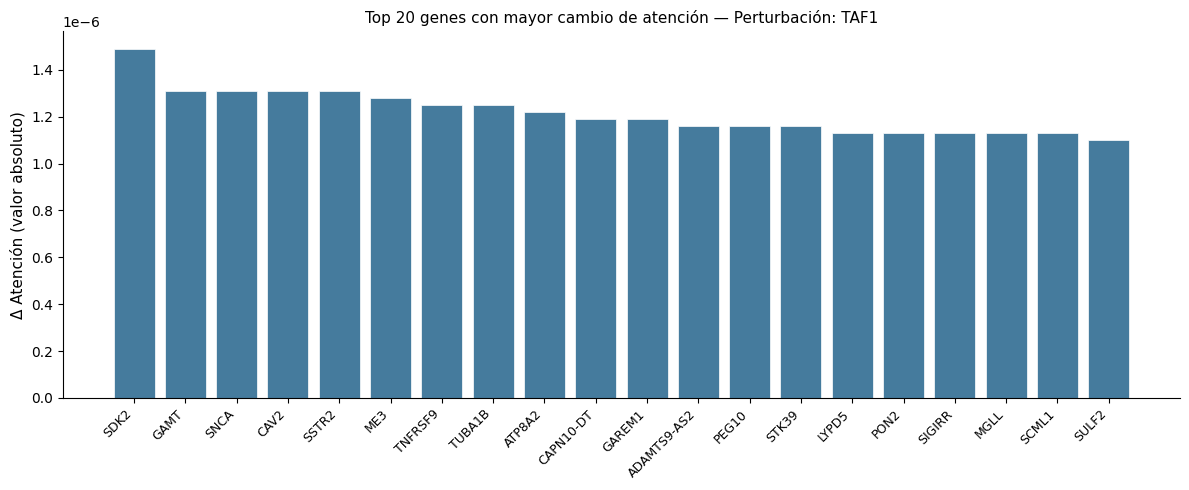

Figura guardada: attn_top20_TAF1.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

genes_plot  = df_topk.head(20).index.tolist()
scores_plot = df_topk.head(20).values
colors      = ["#e63946" if g == GEN_PERTURBADO else "#457b9d" for g in genes_plot]

bars = ax.bar(range(len(genes_plot)), scores_plot, color=colors, edgecolor="white", linewidth=0.5)

ax.set_xticks(range(len(genes_plot)))
ax.set_xticklabels(genes_plot, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Δ Atención (valor absoluto)", fontsize=11)
ax.set_title(
    f"Top 20 genes con mayor cambio de atención — Perturbación: {GEN_PERTURBADO}",
    fontsize=11
)

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"attn_top20_{GEN_PERTURBADO}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: attn_top20_{GEN_PERTURBADO}.png")


## 8. Análisis de enriquecimiento funcional (g:Profiler)

Para el enriquecimiento se usa la lista de genes del **método CLS** (`df_cls`),
que es el método que produce resultados significativos consistentes con el tutorial
original de la tutora.

El **método CLS** extrae la fila 0 de la matriz de atención diferencial:
cuánto el token `<cls>` (representación global de la célula) atiende a cada gen
en células perturbadas vs. control.

El **método `get_topk`** (sección 8) sigue siendo útil para identificar genes
con mayor cambio de atención *entrante* desde toda la secuencia, y aparece en el
resumen final como lista complementaria.

**Background:** Genes del dataset adjuntado (capturados antes del filtro HVG).
Si no hay términos significativos con este background, se aplica un fallback automático
con los 2,000 genes HVG, que es el comportamiento del notebook original.

In [20]:
GP_SOURCES = ["GO:BP", "GO:MF", "GO:CC", "KEGG", "REAC"]
gp_client  = GProfiler(return_dataframe=True)

# Análisis de sobre-representación con g:Profiler y background personalizado.
def run_gprofiler_enrich(gene_list, background):

    try:
        df = gp_client.profile(
            organism="hsapiens",
            query=gene_list,
            sources=GP_SOURCES,
            no_iea=True,
            no_evidences=False,
            significance_threshold_method="g_SCS",
            domain_scope="custom",
            background=background,
        )
        if df.empty:
            return pd.DataFrame()
        return df[df["significant"]].copy()
    except Exception as exc:
        print(f"Error en g:Profiler: {exc}")
        return pd.DataFrame()


# ── Selección de genes para el enriquecimiento ──
# Se usa df_cls (fila 0 de la matriz de atención) porque captura directamente qué genes contribuyen más a la representación global de la célula.
top_genes_enrich = df_cls.abs().nlargest(TOP_K_GENES).index.tolist()

print(f"Genes en query   : {len(top_genes_enrich)}  (top-{TOP_K_GENES} por |score CLS|)")
print(f"Background       : {len(background_genes):,} genes (pre-HVG, en vocab scGPT)")
print("Lanzando enriquecimiento...\n")

sig_df = run_gprofiler_enrich(top_genes_enrich, background_genes)

if not sig_df.empty:
    print(f"Términos significativos encontrados: {len(sig_df)}")
    display_cols = ["source", "name", "term_size", "p_value"]
    print("\n" + sig_df[display_cols].head(100).to_string(index=False))
else:
    print("No se encontraron términos significativos con background pre-HVG.")
    print("Probando con background HVG (2,000 genes) como fallback...\n")
    background_hvg = adata.var.index.tolist()
    sig_df = run_gprofiler_enrich(top_genes_enrich, background_hvg)
    if not sig_df.empty:
        print(f"[Fallback HVG] Términos significativos: {len(sig_df)}")
        print(sig_df[["source", "name", "term_size", "p_value"]].head(50).to_string(index=False))
    else:
        print("Sin términos significativos tampoco con background HVG.")
        print("Sugerencia: aumenta TOP_K_GENES a 300-500.")


Genes en query   : 200  (top-200 por |score CLS|)
Background       : 23,325 genes (pre-HVG, en vocab scGPT)
Lanzando enriquecimiento...

Términos significativos encontrados: 59

source                                          name  term_size      p_value
 GO:CC                 cellular anatomical structure      16453 1.951065e-13
 GO:CC                            cellular_component      16598 8.162369e-13
 GO:CC            intracellular anatomical structure      13487 1.451192e-10
 GO:MF                            molecular_function      16815 4.955131e-10
 GO:CC                                     cytoplasm      10742 7.213887e-09
 GO:BP              regulation of biological process       9983 2.323849e-08
 GO:BP                              cellular process      14725 6.526299e-08
 GO:BP                         biological regulation      10345 6.973648e-08
 GO:BP                            biological_process      15684 1.095774e-07
 GO:MF                                       binding

## 9. Figura de enriquecimiento (dotplot)

Se va realizar un overlap de los 100 genes más influenciados y todas las anotaciones que se encuentran disponibles en distintas bases de datos biológicas como la Gene Ontology (GO), la Kyoto Encyclopedia of Genes and Genomess (KEGG) o REAC mediante la librería gprofiler.

Visualizamos los términos más significativos. El eje x es el -log10(p-valor), el tamaño del punto es el número de genes del query que se solapan con el término, y el color indica la fuente (GO, KEGG, REAC).

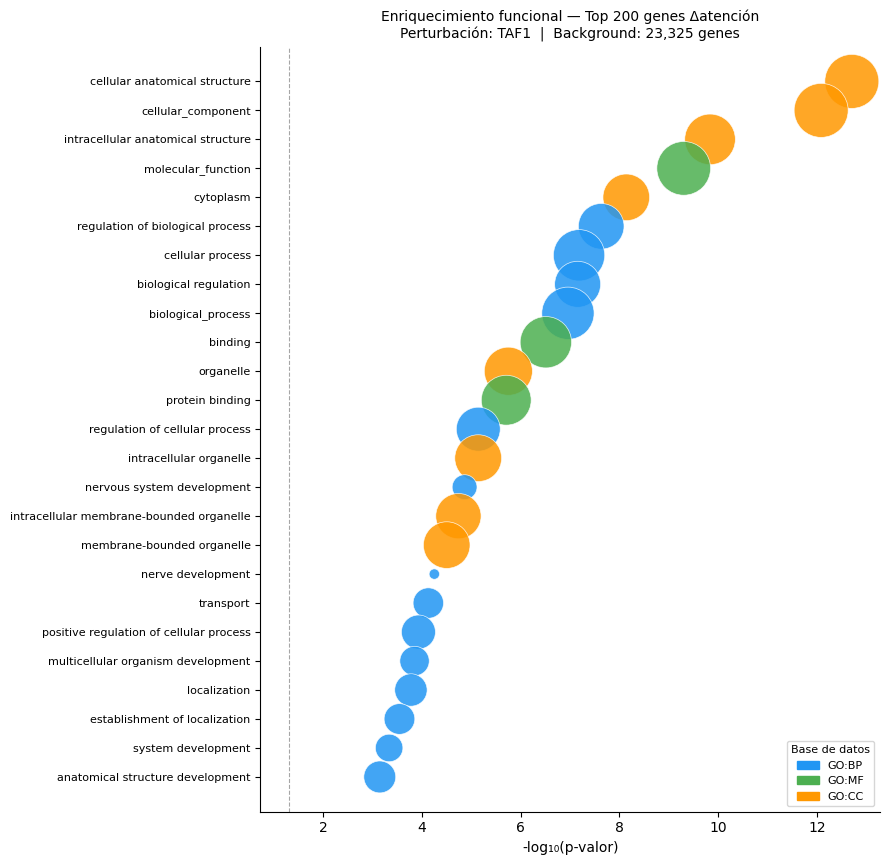

Figura guardada: enrichment_dotplot_TAF1.png


In [ ]:
if not sig_df.empty:
    # Tomar los N términos más significativos para la figura
    N_TERMS_PLOT = min(25, len(sig_df))
    plot_df = (
        sig_df
        .sort_values("p_value")
        .head(N_TERMS_PLOT)
        .copy()
    )
    plot_df["-log10_pval"] = -np.log10(plot_df["p_value"].clip(lower=1e-300))

    # Paleta de colores por fuente
    source_colors = {
        "GO:BP": "#2196F3",
        "GO:MF": "#4CAF50",
        "GO:CC": "#FF9800",
        "KEGG":  "#9C27B0",
        "REAC":  "#F44336",
    }
    colors_dot = [source_colors.get(s, "gray") for s in plot_df["source"]]

    fig, ax = plt.subplots(figsize=(9, max(5, N_TERMS_PLOT * 0.35)))

    scatter = ax.scatter(
        plot_df["-log10_pval"],
        range(len(plot_df)),
        c=colors_dot,
        s=plot_df["intersection_size"] * 8,
        alpha=0.85,
        edgecolors="white",
        linewidths=0.5,
    )

    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(
        [f"{row['name'][:50]}" for _, row in plot_df.iterrows()],
        fontsize=8
    )
    ax.set_xlabel("-log₁₀(p-valor)", fontsize=10)
    ax.set_title(
        f"Enriquecimiento funcional — Top {TOP_K_GENES} genes Δatención\n"
        f"Perturbación: {GEN_PERTURBADO}  |  Background: {len(background_genes):,} genes",
        fontsize=10
    )

    # Línea de significancia p=0.05
    ax.axvline(x=-np.log10(0.05), color="gray", linestyle="--",
               linewidth=0.8, alpha=0.7, label="p = 0.05")

    # Leyenda de fuentes
    source_patches = [
        mpatches.Patch(color=c, label=s)
        for s, c in source_colors.items()
        if s in plot_df["source"].values
    ]
    ax.legend(handles=source_patches, title="Base de datos",
              loc="lower right", fontsize=8, title_fontsize=8)

    ax.invert_yaxis()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()

    fig_name = f"enrichment_dotplot_{GEN_PERTURBADO}.png"
    plt.savefig(fig_name, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figura guardada: {fig_name}")
else:
    print("Sin términos significativos para visualizar.")

## 10. Resumen final del pipeline

In [ ]:
from IPython.display import display, HTML
import numpy as np # Importamos numpy para el formateo opcional si 's' no es float crudo

# 1. Extracción y preparación de variables
n_ctrl  = len(adata.obs[adata.obs[CONDITION_COL] == CTRL_LABEL])
n_pert  = len(adata.obs[adata.obs[CONDITION_COL] == PERT_LABEL])
n_hvg   = adata.shape[1]
n_bg    = len(background_genes)
n_terms = len(sig_df) if not sig_df.empty else 0

# 2. Generar bloque de la lista del Top 20 de genes con 9 decimales
genes_html = ""
# Tomamos exactamente los 20 primeros
top20_items = df_topk.head(20).items()

for i, (g, s) in enumerate(top20_items, 1):
    # Destacamos visualmente si el gen perturbado aparece en el top
    if g == GEN_PERTURBADO:
        marker = "← gen perturbado"
        color = "#cf222e" # Rojo destacar
        weight = "bold"
    else:
        marker = ""
        color = "#24292f" # Gris oscuro estándar
        weight = "normal"
    
    score_val = float(s)
    formatted_score = f"{score_val:.9f}"
        
    genes_html += f"""
    <li style='margin-bottom: 6px; color: {color}; font-weight: {weight}; display: flex; justify-content: space-between; align-items: center;'>
        <span><b>{i}.</b> {marker}{g}</span>
        <span style='color: #57606a; font-size: 0.9em; font-family: monospace; background-color: #f1f3f5; padding: 2px 4px; border-radius: 3px;'>
            Δ={formatted_score}
        </span>
    </li>"""

# 3. Generar bloque del Top 5 de términos de enriquecimiento
terms_html = ""
num_terms_to_show = 5

if not sig_df.empty:
    # Ordenamos por p-value y tomamos el Top 5
    top_enrich = sig_df.sort_values("p_value").head(num_terms_to_show)
    actual_terms_shown = len(top_enrich)
    
    for _, row in top_enrich.iterrows():
        # Formateamos la fuente (GO, KEGG, etc.) como una pequeña etiqueta
        terms_html += f"""
        <li style='margin-bottom: 12px; line-height: 1.4; border-bottom: 1px solid #f1f3f5; padding-bottom: 8px;'>
            <div style='margin-bottom: 4px;'>
                <span style='background-color: #ddf4ff; color: #0969da; padding: 2px 6px; border-radius: 4px; font-size: 0.85em; font-weight: 600; margin-right: 5px; font-family: monospace;'>{row['source']}</span> 
                <span style='font-weight: 500; color: #24292f;'>{row['name'][:60]}...</span>
            </div>
            <div style='color: #57606a; font-size: 0.85em; padding-left: 5px;'>
                ID: <span style='font-family: monospace;'>{row['native']}</span> | p-value: <b>{row['p_value']:.2e}</b>
            </div>
        </li>"""
    
    # Ajustamos el título dinámicamente si hay menos de 5
    enrich_title = f"Top {actual_terms_shown} Vías Significativas" if n_terms > 1 else "Vía Significativa"
else:
    terms_html = "<li style='color: #7f8c8d; font-style: italic; text-align: center; padding: 20px 0;'>No se encontraron vías significativas para este top de genes.</li>"
    enrich_title = "Enriquecimiento Biológico"

# 4. Construcción de la tarjeta (Dashboard HTML/CSS)
html_template = f"""
<div style="border: 1px solid #d0d7de; border-radius: 8px; padding: 20px; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Helvetica, Arial, sans-serif; background-color: #f6f8fa; max-width: 900px; box-shadow: 0 3px 6px rgba(0,0,0,0.04); margin: 10px 0;">
    
    <h2 style="margin-top: 0; color: #24292f; border-bottom: 2px solid #d0d7de; padding-bottom: 12px; font-size: 20px; display: flex; align-items: center; gap: 10px;">
        <span style="font-size: 24px;"></span> Resumen de Pipeline — Perturbación: <span style="color: #0969da; font-family: monospace; background-color: #ddf4ff; padding: 2px 8px; border-radius: 4px;">{GEN_PERTURBADO}</span>
    </h2>
    
    <div style="display: flex; justify-content: space-between; margin-bottom: 20px; background: white; padding: 15px; border-radius: 6px; border: 1px solid #d0d7de;">
        <div style="text-align: center; flex: 1; border-right: 1px solid #e1e4e8;">
            <div style="font-size: 28px; font-weight: 600; color: #2da44e;">{n_ctrl:,}</div>
            <div style="font-size: 11px; color: #57606a; text-transform: uppercase; font-weight: 600; letter-spacing: 0.5px; margin-top: 4px;">Células Control</div>
        </div>
        <div style="text-align: center; flex: 1; border-right: 1px solid #e1e4e8;">
            <div style="font-size: 28px; font-weight: 600; color: #cf222e;">{n_pert:,}</div>
            <div style="font-size: 11px; color: #57606a; text-transform: uppercase; font-weight: 600; letter-spacing: 0.5px; margin-top: 4px;">Células Perturbadas</div>
        </div>
        <div style="text-align: center; flex: 1; border-right: 1px solid #e1e4e8;">
            <div style="font-size: 28px; font-weight: 600; color: #24292f;">{n_hvg:,}</div>
            <div style="font-size: 11px; color: #57606a; text-transform: uppercase; font-weight: 600; letter-spacing: 0.5px; margin-top: 4px;">Genes HVG Analizados</div>
        </div>
        <div style="text-align: center; flex: 1;">
            <div style="font-size: 28px; font-weight: 600; color: #8250df;">{n_bg:,}</div>
            <div style="font-size: 11px; color: #57606a; text-transform: uppercase; font-weight: 600; letter-spacing: 0.5px; margin-top: 4px;">Fondo Estadístico</div>
        </div>
    </div>

    <div style="display: flex; gap: 20px; align-items: flex-start;">
        
        <div style="flex: 1.3; background: white; padding: 20px; border-radius: 6px; border: 1px solid #d0d7de; box-shadow: inset 0 0 10px rgba(0,0,0,0.02);">
            <h3 style="margin-top: 0; color: #24292f; font-size: 16px; border-bottom: 1px solid #eaecef; padding-bottom: 10px; margin-bottom: 15px; display: flex; align-items: center; gap: 8px;">
                <span style="color: #cf222e;"></span> Top 20 Genes (Δ Atención Absoluta)
            </h3>
            <ul style="list-style-type: none; padding-left: 0; margin: 0; font-size: 13px;">
                {genes_html}
            </ul>
        </div>
        
        <div style="flex: 1; display: flex; flex-direction: column; gap: 20px;">
            <div style="background: white; padding: 20px; border-radius: 6px; border: 1px solid #d0d7de; box-shadow: inset 0 0 10px rgba(0,0,0,0.02);">
                <h3 style="margin-top: 0; color: #24292f; font-size: 16px; border-bottom: 1px solid #eaecef; padding-bottom: 10px; margin-bottom: 15px; display: flex; align-items: center; gap: 8px;">
                    <span style="color: #0969da;"></span> {enrich_title}
                </h3>
                <p style="margin: 0 0 15px 0; font-size: 13px; color: #24292f; background-color: #f6f8fa; padding: 10px; border-radius: 4px; border: 1px solid #e1e4e8;">
                    Términos significativos totales detectados: <b style="color: #0969da; font-size: 16px; font-family: monospace;">{n_terms:,}</b>
                </p>
                
                <ul style="list-style-type: none; padding-left: 0; margin: 0; font-size: 13px;">
                    {terms_html}
                </ul>
            </div>
        </div>
        
    </div>
</div>
"""

# 5. Renderizar el HTML en el output de Jupyter
display(HTML(html_template))
